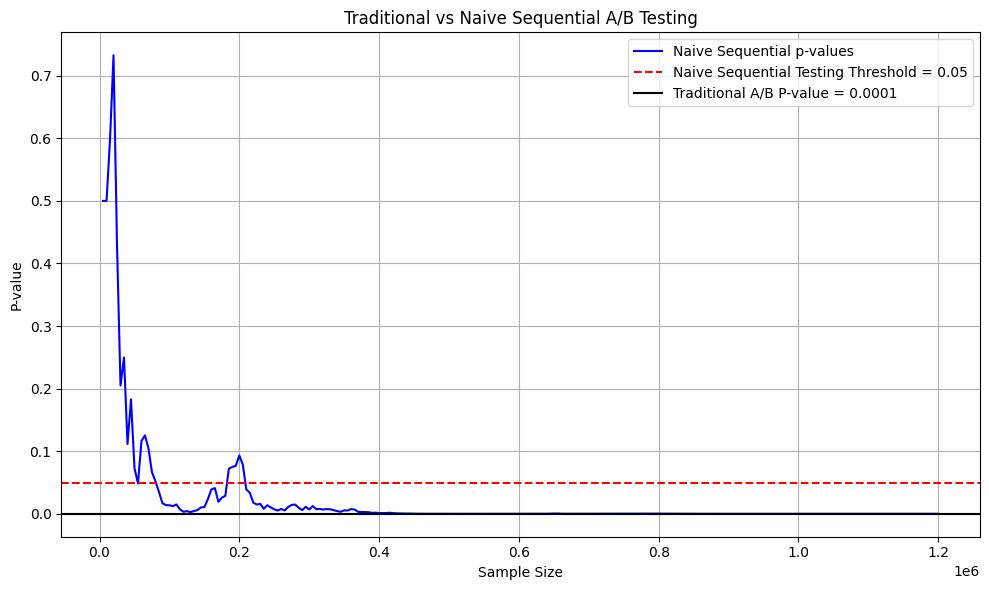

In [5]:
#This implementation helps compare the traditional A/B testing duration v/s the naive Sequential Testing approach without Bonferroni correction
#Import the python libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Step 1: Simulate data
# Control baseline conversion rate is 0.5% 
# Test conversion rate is assumed to have a 6% relative lift
# From the power analysis we need 1.2M in each control and test to achieve statistical significance. 
# Pre defined intervals (i.e. 5000) for inferring the results

np.random.seed(42)
control_rate = 0.005
variant_rate = 0.0053
sample_size = 1200000
check_interval = 5000

#Step 2: Generate 2 binomial distributions for control and test population
control = np.random.binomial(1, control_rate, sample_size)
variant = np.random.binomial(1, variant_rate, sample_size)

# Step 3: Traditional A/B Test at full sample
conv_a_full = np.mean(control)
conv_b_full = np.mean(variant)
pooled_full = (conv_a_full + conv_b_full) / 2
se_full = np.sqrt(2 * pooled_full * (1 - pooled_full) / sample_size)
z_full = (conv_b_full - conv_a_full) / se_full
p_full = 1 - norm.cdf(z_full)

# Step 4: Naive Sequential Testing
samples_list = []
p_naive = []

for i in range(check_interval, sample_size + 1, check_interval):
    conv_a = np.mean(control[:i])
    conv_b = np.mean(variant[:i])
    pooled = (conv_a + conv_b) / 2
    se = np.sqrt(2 * pooled * (1 - pooled) / i)
    z = (conv_b - conv_a) / se
    p = 1 - norm.cdf(z)
    
    samples_list.append(i)
    p_naive.append(p)

# Step 5: Visualization
plt.figure(figsize=(10, 6))
plt.plot(samples_list, p_naive, label='Naive Sequential p-values', color='blue')
plt.axhline(y=0.05, color='red', linestyle='--', label='Naive Sequential Testing Threshold = 0.05')
plt.axhline(y=p_full, color='black', linestyle='-', label=f'Traditional A/B P-value = {p_full:.4f}')
plt.title("Traditional vs Naive Sequential A/B Testing")
plt.xlabel("Sample Size")
plt.ylabel("P-value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

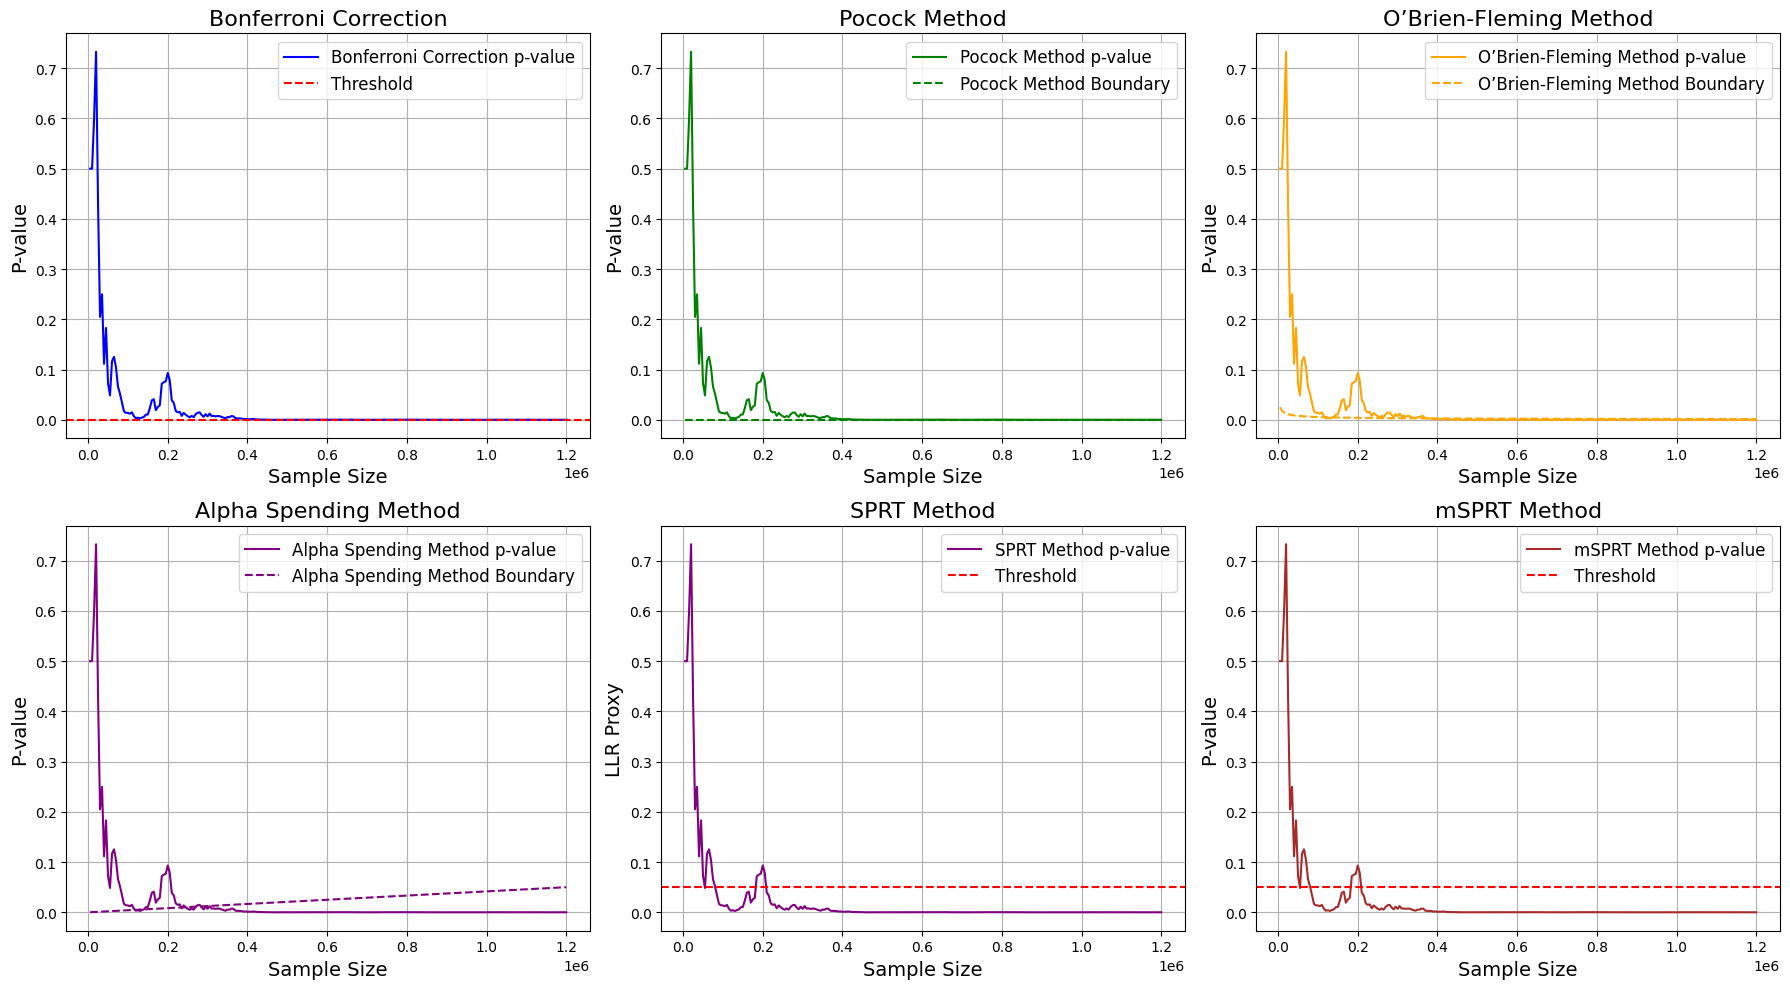

In [15]:
# Track data
samples_list = []
p_bonferroni, p_pocock, p_obf, p_alpha_spend, p_sprt, p_msprt  = [], [], [], [], [], []
boundary_pocock, boundary_obf, boundary_alpha = [], [], []
stop_bonferroni = stop_pocock = stop_obf = stop_alpha = stop_sprt = stop_msprt  = None
alpha = 0.05
looks = sample_size // check_interval
bonf_threshold = alpha / looks
pocock_z = norm.ppf(1 - alpha / looks)

# Functions for boundaries
def obrien_fleming_boundary(alpha, look, total_looks):
    return norm.ppf(1 - (alpha / 2) / np.sqrt(look))

# Alpha spending function: linear (simplified)
def linear_alpha_spend(total_looks, current_look, alpha=0.05):
    return alpha * current_look / total_looks

# SPRT thresholds
A = np.log((1 - alpha) / alpha)
B = np.log(alpha / (1 - alpha))

# Sequential test with mSPRT and alpha spending
for idx, i in enumerate(range(check_interval, sample_size + 1, check_interval), 1):
    conv_a = np.mean(control[:i])
    conv_b = np.mean(variant[:i])
    pooled = (conv_a + conv_b) / 2
    se = np.sqrt(2 * pooled * (1 - pooled) / i)
    z = (conv_b - conv_a) / se
    p = 1 - norm.cdf(z)

    samples_list.append(i)
    p_bonferroni.append(p)
    p_pocock.append(p)
    p_obf.append(p)
    p_alpha_spend.append(p)
    p_sprt.append(p)
    p_msprt.append(p)

    # Bonferroni
    if not stop_bonferroni and p < bonf_threshold:
        stop_bonferroni = i

    # Pocock
    pocock_p = 1 - norm.cdf(pocock_z)
    boundary_pocock.append(pocock_p)
    if not stop_pocock and p < pocock_p:
        stop_pocock = i

    # O'Brien-Fleming
    obf_z = obrien_fleming_boundary(alpha, idx, looks)
    obf_p = 1 - norm.cdf(obf_z)
    boundary_obf.append(obf_p)
    if not stop_obf and p < obf_p:
        stop_obf = i

    # Alpha spending
    current_alpha = linear_alpha_spend(looks, idx)
    current_z = norm.ppf(1 - current_alpha)
    alpha_p = 1 - norm.cdf(current_z)
    boundary_alpha.append(alpha_p)
    if not stop_alpha and p < alpha_p:
        stop_alpha = i

    #SPRT
    llr_sprt = i * ((conv_b - conv_a)**2) / (2 * pooled * (1 - pooled) + 1e-8)
    if not stop_sprt and llr_sprt > A:
        stop_sprt = i

    #mSPRT
    llr_msprt = i * ((conv_b - conv_a)**2) / (2 * pooled * (1 - pooled) + 1e-8)
    if not stop_msprt and llr_msprt > 3.84:
        stop_msprt = i


# Plotting
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

titles = ["Bonferroni Correction", "Pocock Method", "O’Brien-Fleming Method", "Alpha Spending Method",
          "SPRT Method", "mSPRT Method"]
p_lists = [p_bonferroni, p_pocock, p_obf, p_alpha_spend, p_sprt, p_msprt]
boundaries = [bonf_threshold, boundary_pocock, boundary_obf, boundary_alpha, 0.05, 0.05]
colors = ['blue', 'green', 'orange', 'purple', 'purple', 'brown']

for idx, ax in enumerate(axes):
    ax.plot(samples_list, p_lists[idx], label=f'{titles[idx]} p-value', color=colors[idx])
    if isinstance(boundaries[idx], list):
        ax.plot(samples_list, boundaries[idx], '--', label=f'{titles[idx]} Boundary', color=colors[idx])
    else:
        ax.axhline(y=boundaries[idx], color='red', linestyle='--', label='Threshold')
    ax.set_title(titles[idx], fontsize=16)
    ax.set_xlabel("Sample Size", fontsize=14)
    ax.set_ylabel("P-value" if idx != 4 else "LLR Proxy",fontsize=14)
    ax.legend(fontsize=12)
    ax.grid(True)

plt.tight_layout()
plt.show()